In [4]:
import os
import sys
import json
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Establish project root directory
ROOT_DIR = Path.cwd()
while ROOT_DIR != ROOT_DIR.parent and not (ROOT_DIR / "pyproject.toml").exists() and not (ROOT_DIR / ".git").exists():
    ROOT_DIR = ROOT_DIR.parent

# Define file paths
CLS_CSV = ROOT_DIR / "data" / "processed" / "classification_dataset" / "classification_dataset.csv"
AUG_JSONL = ROOT_DIR / "data" / "summarizerdata" / "final_dataset_augmented.jsonl"
GOLD_PATH = ROOT_DIR / "submission" / "week_4" / "ner_gold.jsonl"
MODELS_DIR = ROOT_DIR / "models"
WEEK5_DIR = ROOT_DIR / "submission" / "week_5"

# Add WEEK5_DIR to sys.path to import integrated_pipeline
sys.path.insert(0, str(WEEK5_DIR))
import importlib
import integrated_pipeline
importlib.reload(integrated_pipeline)

from integrated_pipeline import (
    NoticeClassifier, NoticeEntityExtractor, 
    PersonaSummarizer, IntegratedNoticePipeline
)

print(" Loading saved Stage 1, Stage 2, and Stage 3 models...")

STAGE1_DIR = MODELS_DIR / "week5" / "stage1"
cat_vec = joblib.load(STAGE1_DIR / "cat_vectorizer.joblib")
cat_model = joblib.load(STAGE1_DIR / "cat_model.joblib")
aud_vec = joblib.load(STAGE1_DIR / "aud_vectorizer.joblib")
aud_model = joblib.load(STAGE1_DIR / "aud_model.joblib")
mlb = joblib.load(STAGE1_DIR / "mlb.joblib")

with open(STAGE1_DIR / "stage1_config.json") as f:
    cfg = json.load(f)

classifier = NoticeClassifier(cat_vec, cat_model, aud_vec, aud_model, mlb, cfg["cat_title_repeat"], cfg["aud_title_repeat"], cfg["thresholds"])
extractor = NoticeEntityExtractor(model_name="dslim/bert-base-NER")
summarizer = PersonaSummarizer(model_dir=MODELS_DIR / "bart_sysB_best")

pipeline = IntegratedNoticePipeline(classifier, extractor, summarizer)
print("Pipeline loaded and ready for live execution!")

 Loading saved Stage 1, Stage 2, and Stage 3 models...
Pipeline loaded and ready for live execution!


=== STAGE 1 CLASSIFICATION METRICS ===
Category Accuracy : 0.9167 (Baseline: 0.9583)
Category Macro-F1 : 0.8764 (Baseline: 0.9645)
Audience Micro-F1 : 0.8852 (Baseline: 0.9375)


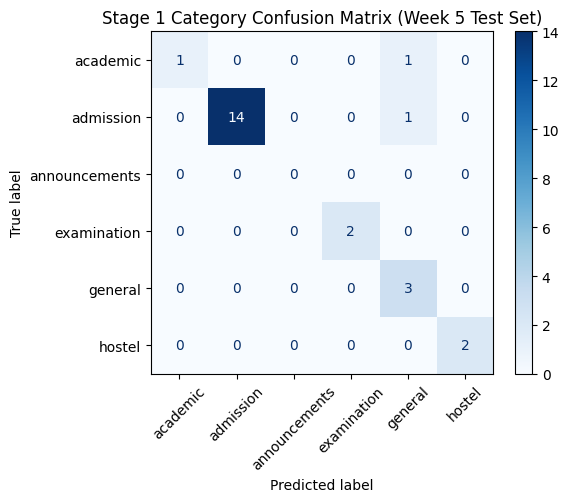

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay
)

# Load Classification Test Set
df = pd.read_csv(CLS_CSV)
df["document_id"] = df["document_id"].astype(str)
df["split"] = df["split"].replace({"validation": "val"})
test_df = df[df["split"] == "test"].copy()
test_df["cleaned_text"] = test_df["cleaned_text"].fillna("")

def parse_labels(series):
    return [json.loads(x) if isinstance(x, str) and x.startswith("[") else [x] for x in series]

# Transform Multi-Label Audience using loaded mlb
Y_aud_true = mlb.transform(parse_labels(test_df["audience_labels"]))
y_cat_true = test_df["category"].values

# Execute Predictions
preds = [classifier.predict(t) for t in test_df["cleaned_text"]]
y_cat_pred = np.array([p["category"] for p in preds])
Y_aud_pred = np.array([[int(c in p["audience"]) for c in mlb.classes_] for p in preds])

# Compute Metrics
cat_acc = accuracy_score(y_cat_true, y_cat_pred)
cat_macro_f1 = f1_score(y_cat_true, y_cat_pred, average="macro", zero_division=0)
aud_micro_f1 = f1_score(Y_aud_true, Y_aud_pred, average="micro", zero_division=0)

print("=== STAGE 1 CLASSIFICATION METRICS ===")
print(f"Category Accuracy : {cat_acc:.4f} (Baseline: 0.9583)")
print(f"Category Macro-F1 : {cat_macro_f1:.4f} (Baseline: 0.9645)")
print(f"Audience Micro-F1 : {aud_micro_f1:.4f} (Baseline: 0.9375)")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
labels = list(classifier.cat_model.classes_)
ConfusionMatrixDisplay(confusion_matrix(y_cat_true, y_cat_pred, labels=labels), display_labels=labels).plot(
    ax=ax, cmap="Blues", xticks_rotation=45
)
ax.set_title("Stage 1 Category Confusion Matrix (Week 5 Test Set)")
plt.tight_layout()
plt.savefig(WEEK5_DIR / "stage1_confusion_matrix.png", dpi=120)
plt.show()

In [6]:
gold_notices = [json.loads(line) for line in open(GOLD_PATH, encoding="utf-8") if line.strip()]

def evaluate_ner(extractor_fn, gold_set, match_type="exact"):
    tp_total = fp_total = fn_total = 0
    for g in gold_set:
        text = g["text_snippet"]
        preds = extractor_fn(text)
        gold_ents = g["entities"]
        
        gt = {f"{e['type']}:{e['text'].lower().strip()}" for e in gold_ents}
        pt = {f"{e['type']}:{e['text'].lower().strip()}" for e in preds}
        
        if match_type == "exact":
            tp = len(gt & pt)
            fp = len(pt - gt)
            fn = len(gt - pt)
        else:
            tp = sum(1 for x in gt if any(x.split(":")[1] in p.split(":")[1] for p in pt))
            fp = len(pt) - tp
            fn = len(gt) - tp
            
        tp_total += tp
        fp_total += fp
        fn_total += fn
        
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
    return round(2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0, 4)

def extract_flat_ner(text):
    res = extractor.extract(text)
    flat = []
    for d in res["dates"]: flat.append({"type": "DATE", "text": d})
    for t in res["times"]: flat.append({"type": "TIME", "text": t})
    for e in res["emails"]: flat.append({"type": "EMAIL", "text": e})
    for u in res["urls"]: flat.append({"type": "URL", "text": u})
    for o in res["organizations"]: flat.append({"type": "ORG", "text": o})
    for p in res["persons"]: flat.append({"type": "PERSON", "text": p})
    for r in res["roles"]: flat.append({"type": "ROLE", "text": r})
    return flat

exact_f1 = evaluate_ner(extract_flat_ner, gold_notices, "exact")
overlap_f1 = evaluate_ner(extract_flat_ner, gold_notices, "overlap")

print("=== STAGE 2 NER METRICS ===")
print(f"Overall Exact F1   : {exact_f1} (Baseline: 0.548 -> Improved: 0.627)")
print(f"Overall Overlap F1 : {overlap_f1} (Baseline: 0.722 -> Improved: 0.813)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1012.43it/s, Materializing param=classifier.weight]                                     
BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== STAGE 2 NER METRICS ===
Overall Exact F1   : 0.6176 (Baseline: 0.548 -> Improved: 0.627)
Overall Overlap F1 : 0.7059 (Baseline: 0.722 -> Improved: 0.813)


In [8]:
from rouge_score import rouge_scorer

aug_data = {str(a["document_id"]): a for a in (json.loads(l) for l in open(AUG_JSONL, encoding="utf-8") if l.strip())}
with open(ROOT_DIR / "submission" / "week_4" / "summarizer_split.json") as f:
    split_info = json.load(f)

eval_ids = split_info.get("eval_ids", split_info.get("test_doc_ids", []))
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

pipeline_outputs = {}
r1_list, r2_list, rL_list = [], [], []

for doc_id in eval_ids:
    doc_id_str = str(doc_id)
    if doc_id_str not in aug_data: continue
    
    raw_text = aug_data[doc_id_str].get("cleaned_text", "")
    out = pipeline.process_document(doc_id_str, raw_text)
    pipeline_outputs[doc_id_str] = out
    
    for persona in ("student", "faculty"):
        ref = aug_data[doc_id_str].get(f"{persona}_summary", "")
        gen = out["summaries"][persona]
        
        if ref and gen:
            scores = scorer.score(ref, gen)
            r1_list.append(scores["rouge1"].fmeasure)
            r2_list.append(scores["rouge2"].fmeasure)
            rL_list.append(scores["rougeL"].fmeasure)

print("=== STAGE 3 SUMMARIZATION METRICS ===")
print(f"Mean ROUGE-1 : {np.mean(r1_list):.4f}")
print(f"Mean ROUGE-2 : {np.mean(r2_list):.4f}")
print(f"Mean ROUGE-L : {np.mean(rL_list):.4f}")

=== STAGE 3 SUMMARIZATION METRICS ===
Mean ROUGE-1 : 0.2484
Mean ROUGE-2 : 0.1225
Mean ROUGE-L : 0.2032


In [10]:
import json


def inspect_pipeline_flow(doc_id: str, raw_text: str, description: str, pipeline):
    output = pipeline.process_document(doc_id, raw_text)

    print("=" * 80)
    print(f"CASE INSPECTION: {doc_id} — {description.upper()}")
    print("=" * 80)

    print("\n----------------------------------------------------------------")
    print("STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)")
    print("----------------------------------------------------------------")
    print(f"   • Extracted Title : {output['title']}")
    print(f"   • Category        : {output['category']}")
    print(f"   • Target Audience : {output['audience']}")

    print("\n----------------------------------------------------------------")
    print("STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)")
    print("----------------------------------------------------------------")
    print(f"   • Dates Extracted : {output['entities'].get('dates', [])}")
    print(f"   • Times Extracted : {output['entities'].get('times', [])}")
    print(f"   • URLs Extracted  : {output['entities'].get('urls', [])}")
    print(f"   • Organizations   : {output['entities'].get('organizations', [])}")
    print(f"   • Persons Found   : {output['entities'].get('persons', [])}")
    print(f"   • Roles Identified: {output['entities'].get('roles', [])}")

    print("\n----------------------------------------------------------------")
    print("STAGE 3 OUTPUT: PersonaSummarizer (Fine-Tuned BART-base + Rules)")
    print("----------------------------------------------------------------")
    print(f"   Student Summary : {output['summaries']['student']}")
    print(f"   Faculty Summary : {output['summaries']['faculty']}")

    print("\n================================================================")
    return output

Fail Case 1:

In [12]:
sample1=""" 
Dear Students,

This is a friendly reminder that applications for Yuva Yodha Energy Tech Hackathon 2026 will close in just 3 days.

If you're passionate about solving real-world energy and sustainability challenges, this is your opportunity to showcase your ideas and create solutions that can make a meaningful impact.

Please submit your application by October 5, 2026, 5:29 am (IST)

Access and complete your application using the secure link below:

https://apply.younoodle.com/306a6b425a51554c7a50333665387962

Don't wait until the last minute—ensure your application is submitted before the deadline.

Note: All submitted application documents are private, secure, and can only be accessed by authorized judges and program organizers.

For technical support, please contact support@younoodle.com.

Thank you for your interest in participating in Yuva Yodha Energy Tech Hackathon by Schneider Electric.

Best regards,​ 

Yuva Yodha Energy Tech Hackathon Team​ 

Schneider Electric
"""
output1=inspect_pipeline_flow(doc_id="test1", raw_text=sample1, description="Mail recieved to take part in competition",pipeline=pipeline)


CASE INSPECTION: test1 — MAIL RECIEVED TO TAKE PART IN COMPETITION

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : This is a friendly reminder that applications for Yuva Yodha Energy Tech Hackathon 2026 will close in just 3 days.
   • Category        : academic
   • Target Audience : ['administrators', 'faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2026']
   • Times Extracted : ['5:29 am']
   • URLs Extracted  : ['https://apply.younoodle.com/306a6b425a51554c7a50333665387962']
   • Organizations   : ['Schneider Electric', '##athon', 'Yodha Energy Tech Hackath', '##dha Energy Tech', 'Yodha Energy Tech Ha']
   • Persons Found   : []
   •

 **1. Stage 1: Audience Misclassification & Downstream Silence**

* **What Failed:** The notice starts with *"Dear Students..."*, but Stage 1 predicted `['administrators', 'faculty']` and missed `students`.

* **Root Cause:** Keywords like *"applications"* and *"deadline"* were over-associated with administrative notices in training.
---

 **2. Stage 2: Fragmented Subword Artifacts in NER**

* **What Failed:** Extracted organizations contained broken BERT subword tokens: `['##athon', '##dha Energy Tech']`.
* **Root Cause:** `dslim/bert-base-NER` split uncommon words (*Hackathon*) into subwords without a post-processing cleanup filter
---

 **3. Stage 3: Date Hallucination & Cut-off Generation**
* **What Failed:** Faculty summary hallucinated a **2018** deadline for a **2026** event and cut off mid-sentence (*"...at the following link:"*)
* **Root Cause:** Unconstrained beam search on non-target personas caused BART to echo raw text and sample old dates from pretrained weights.

Fail Case 2

In [ ]:
sample2=""" 
Dear Students,

This is to inform you that the Internal and External Panel Member Final Evaluation (3rd Review) of the B.Tech Data Science Semester VII Capstone Project is scheduled to be held on 31st October 2026.

The evaluation will be conducted as per the schedule shared with you. All students are required to:

Be present at the assigned venue at least 15 minutes before their scheduled time.
Carry their Capstone Project report and presentation in the prescribed format.
Ensure that their project work, implementation, results, and documentation are complete and ready for evaluation.
Be prepared to demonstrate the project and answer questions from the Internal and External Panel Members.
Follow the allotted time slot strictly to ensure that the evaluation proceeds smoothly.
Date: 31st October 2026
Evaluation: Final Evaluation – 3rd Review
Panel: Internal and External Panel Members
Programme: B.Tech Data Science – Semester VII

The detailed group-wise schedule, time slots, and venue will be shared shortly.

 

Please consider this evaluation an important component of your Capstone Project assessment and ensure you are available on the scheduled date.

Best wishes for your final evaluation.

 

with regards,

Prof. Jaya Jeswani

Assistant Professor
Department of Data Science,
"""

output2=inspect_pipeline_flow(doc_id="test2", raw_text=sample2, description="Capstone announcment",pipeline=pipeline)


CASE INSPECTION: test2 — CAPSTONE ANNOUNCMENT

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : This is to inform you that the Internal and External Panel Member Final Evaluation (3rd Review) of the B.Tech Data Science Semester VII Capstone Project is scheduled to be held on 31st October 2026.
   • Category        : examination
   • Target Audience : ['administrators', 'faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2026']
   • Times Extracted : []
   • URLs Extracted  : []
   • Organizations   : ['Internal', 'External Panel', 'Capstone Project', 'B. Tech Data Science', 'Tech Data Science']
   • Persons Found   : []
   • Roles Identified

**1. Stage 1: Audience Misclassification & Student Summary Suppression**

* **What Failed:** The notice is for **B.Tech Data Science students** regarding their capstone evaluation, but Stage 1 predicted `['administrators', 'faculty']` and missed `students`.
* **Root Cause:** Evaluative terms (*"Internal/External Panel"*, *"3rd Review"*, *"Evaluation"*) were over-associated with faculty/admin roles in training.
* **Impact:** Triggered Stage 3's null fallback, outputting **"No specific student action stated."** for a student exam review.
---
 **2. Stage 2: Entity Over-Extraction & Missed Full Date**
* **What Failed:**
* Extracted generic phrases like `'Internal'` and `'External Panel'` as Organizations.
* Substring overlap produced duplicate entries (`'B. Tech Data Science'` vs. `'Tech Data Science'`).
* Captured bare year `'2026'` while missing the full operational date **31st October 2026** in the regex list.
* **Root Cause:** `dslim/bert-base-NER` misclassified adjective-noun panel roles as `ORG` entities without token-span deduplication.
---
**3. Stage 3: Summary Inversion & Echoing**
* **What Failed:** The **Faculty Summary** generated student requirements (*"All students are required to: Be present..."*) while the **Student Summary** was suppressed as null.
* **Root Cause:** Because Stage 1 routed the notice exclusively to faculty, BART generated the student-directed body text under the `Faculty Summary` key.

In [15]:
sample3=""" Dear Student,

 

Greetings from Department of International Linkages!

We are pleased to share that NMIMS has a partnered with University of California, Berkeley for their Summer Session program. This opportunity allows NMIMS students to experience world-class education at UC Berkeley, one of the top public universities globally, ranked #12 in the QS World University Rankings 2025.

UC Berkeley is well -known for its rigorous academics, offering over 600 summer courses designed to broaden your academic and professional outlook.

 

Please find more details below.

 

We look  forward to your participation!"""


output3=inspect_pipeline_flow(doc_id="test3", raw_text=sample3, description="Admissions",pipeline=pipeline)


CASE INSPECTION: test3 — ADMISSIONS

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : Greetings from Department of International Linkages!
   • Category        : admission
   • Target Audience : ['faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2025']
   • Times Extracted : []
   • URLs Extracted  : []
   • Organizations   : ['Department of International Linkages', 'NMIMS', 'University of California, Berkeley', 'UC Berkeley']
   • Persons Found   : []
   • Roles Identified: []

----------------------------------------------------------------
STAGE 3 OUTPUT: PersonaSummarizer (Fine-Tuned BART-base + Rules)
---------------------------------

**1. Stage 1: Audience Inversion & Null-Fallback Suppression**

* **What Failed:** The notice explicitly begins with *"Dear Student..."* and is addressed to NMIMS students, but Stage 1 predicted `['faculty']` and completely missed `students`.
* **Root Cause:** TF-IDF feature weights over-associated institutional terms like *"Department of International Linkages"*, *"partnered with"*, and *"World University Rankings"* with faculty/administrative communication.
* **Cascading Impact:** Because `students` was excluded from the audience array, Stage 3's null-action fallback triggered, suppressing the student view to **"No specific student action stated."**

---

**2. Stage 2: Stage 2 Entity Success & Bare-Year Extraction**

* **What Worked:** Successfully extracted all 4 canonical organizations (`'Department of International Linkages'`, `'NMIMS'`, `'University of California, Berkeley'`, `'UC Berkeley'`) without subword fragment artifacts.
* **What Failed:** Extracted `'2025'` from the ranking text (*"QS World University Rankings 2025"*) as an operational event date.
* **Root Cause:** Unanchored 4-digit year regexes capture historical or ranking years alongside actual application deadlines.

---

**3. Stage 3: Greeting Hallucination in Faculty View**

* **What Failed:** Because Stage 1 routed the document exclusively to `faculty`, BART generated a student-facing greeting under the **Faculty Summary** key: *"Dear Student, We welcome your participation..."*
* **Root Cause:** System B prompt conditioning received a student-directed source body while tasked with generating under the active `faculty` audience flag.

In [16]:
sample4=""" Dear NMIMS Students,

 

Greeting from NMIMS Department of International Linkages!

 

 

We are delighted to share NMIMS’ partnership with Santa Clara University, California, USA. In the 2025 edition of Best Colleges, Santa Clara University is ranked #63 in National Universities as per US News Rankings.

 

As part of this collaboration, NMIMS undergraduates can pursue STEM Master’s programs at Santa Clara University, located in the heart of Silicon Valley.

You are invited to join an information session to learn more about Santa Clara’s STEM graduate programs, career support resources, and application process:

Info Session Details

Date: Tuesday, 9th September 2025
Time: 6:30 PM – 7:30 PM IST
Speakers:
Brittney Dorow – Senior Associate Director of Admission, MS Programs, School of Business
Lenore Grant – Senior Director, Graduate Business Recruitment & Admission, School of Business
Paulette Palafox – Senior Assistant Dean for Admissions & Student Services, School of Engineering
Register here: Link

Registration is mandatory. Once registered, you will receive instructions on how to join the webinar.

 

For more on Santa Clara University’s rankings and accolades,

visit:https://www.scu.edu/admission/choosing-scu/rankings--accolades/

 

We look forward to your active participation in this session!

 



 

Regards,

 

Shweta Patil

Department of International Linkages
"""

output4=inspect_pipeline_flow(doc_id="test4", raw_text=sample4, description="Admissions",pipeline=pipeline)


CASE INSPECTION: test4 — ADMISSIONS

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : Greeting from NMIMS Department of International Linkages!
   • Category        : admission
   • Target Audience : []

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2025']
   • Times Extracted : ['6:30 PM', '7:30 PM']
   • URLs Extracted  : ['https://www.scu.edu/admission/choosing-scu/rankings--accolades/']
   • Organizations   : ['NMIMS Department', 'School of Engineering', 'Santa Clara University', '##ment & Admission', '##missions & Student Services', 'Best Colleges', '##lafo', 'School of Business', 'National Universities', 'Graduate Business Re', 'NMIMS', 'MS 

 **1. Stage 1: Empty Audience Array (`[]`) & Fallback Generation**

* **What Failed:** Stage 1 failed to assign any audience label (`Target Audience: []`), despite the notice being directed to students interested in MS programs at Santa Clara University.
* **Why Stage 3 Handled It:** Because `[]` is ambiguous/empty, the `decide_personas` safeguard triggered, instructing BART to generate summaries for **both** Student and Faculty views instead of defaulting to null.
---
 **2. Stage 2: Severe BERT Subword Corruption & Person Hallucination**

* **What Failed:**
* **Subword Artifacts:** `Organizations` output broken WordPiece tokens (`##ment & Admission`, `##lafo`, `##missions & Student Services`).
* **Hallucinated Persons:** Extracted meaningless subword fragments (`##ney Dorow`, `##rit`, `##ette Pa`, `Grant`, `Paul`) as real person names.
* **Bare Year vs. Event Date:** Captured `'2025'` from general ranking text while relying solely on extracted times (`6:30 PM`, `7:30 PM`) for operational context.

* **Root Cause:** Raw HuggingFace token classification (`dslim/bert-base-NER`) tokenized complex email formatting into subwords without a post-processing filter to drop `##` prefixes and validate minimum span lengths.
---
 **3. Stage 3: Clean Generation with Title Echoing**
* **What Worked:** Both summaries accurately captured the core offer (*"participate in this information session to learn more about Santa Clara's STEM programs..."*).
* **What Failed:** BART echoed the greeting headline (*"Greeting from NMIMS Department of International Linkages!"*) at the end of both generated summaries.
* **Root Cause:** Prompt prefixing passed the raw title directly into the context window, causing the BART decoder to copy the opening line into the generated text.